# 04 — Acquisition Channel Analysis

The goal here is to answer: **which acquisition channels bring customers who stay and grow?**

I use two complementary views:
- Historical churn comparison: channel mix among churned vs non-churned tenants.
- Snapshot forward view (as of `2024-06-30`): 90-day retention plus grow potential.

For grow potential, I use `expansion_signal` derived in notebook `02_prechurn_analysis_and_feature_store`.



In [7]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[0]
SNAPSHOT_DATE = pd.Timestamp("2024-06-30")

feature_store = pd.read_csv(
    PROJECT_ROOT / "results" / "tenant_feature_store_snapshot_2024_06_30.csv",
    parse_dates=["churn_date", "next_renewal_date", "contract_start_date", "renewal_date"],
)

required_cols = [
    "tenant_id",
    "acquisition_source",
    "snapshot_active",
    "churned",
    "churn_90d",
    "expansion_signal",
]


# View 1: Historical channel mix by churn status.
historical = (
    feature_store.groupby("acquisition_source", as_index=False)
    .agg(
        tenants=("tenant_id", "nunique"),
        churned_tenants=("churned", "sum"),
    )
)
historical["churn_rate"] = historical["churned_tenants"] / historical["tenants"]
historical["retention_rate"] = 1 - historical["churn_rate"]
historical = historical.sort_values(["churn_rate", "tenants"], ascending=[True, False]).reset_index(drop=True)

print("Historical churn comparison by acquisition channel")
display(
    historical[
        [
            "acquisition_source",
            "tenants",
            "churned_tenants",
            "churn_rate",
            "retention_rate",
        ]
    ]
)

# View 2: Snapshot-forward stay + grow potential for active tenants at snapshot.
active_snapshot = feature_store.loc[feature_store["snapshot_active"] == 1].copy()

snapshot_view = (
    active_snapshot.groupby("acquisition_source", as_index=False)
    .agg(
        tenants=("tenant_id", "nunique"),
        retention_90d=("churn_90d", lambda s: 1 - s.mean()),
        grow_potential=("expansion_signal", "mean"),
    )
)

# Composite score: stay gets slightly higher weight than grow potential.
snapshot_view["stay_and_grow_score"] = (
    0.60 * snapshot_view["retention_90d"] + 0.40 * snapshot_view["grow_potential"]
)

snapshot_view = snapshot_view.sort_values(
    ["stay_and_grow_score", "tenants"], ascending=[False, False]
).reset_index(drop=True)

print("Snapshot-active channels ranked by stay + grow potential")
display(
    snapshot_view[
        [
            "acquisition_source",
            "tenants",
            "retention_90d",
            "grow_potential",
            "stay_and_grow_score",
        ]
    ]
)

best_channel = snapshot_view.iloc[0]["acquisition_source"] if len(snapshot_view) else "N/A"
print(f"Top channel on stay+grow score: {best_channel}")



Historical churn comparison by acquisition channel


,acquisition_source,tenants,churned_tenants,churn_rate,retention_rate
0,referral,89,11,0.123596,0.876404
1,trial,110,15,0.136364,0.863636
2,partner,100,14,0.140000,0.860000
3,outbound,98,14,0.142857,0.857143
4,inbound,103,21,0.203883,0.796117


Snapshot-active channels ranked by stay + grow potential


,acquisition_source,tenants,retention_90d,grow_potential,stay_and_grow_score
0,referral,81,0.962963,0.613253,0.823079
1,trial,99,0.959596,0.606666,0.818424
2,outbound,90,0.955556,0.611827,0.818064
3,partner,91,0.945055,0.572955,0.796215
4,inbound,89,0.921348,0.603603,0.794250


Top channel on stay+grow score: referral


## Visuals: Which Channels Stay and Grow?



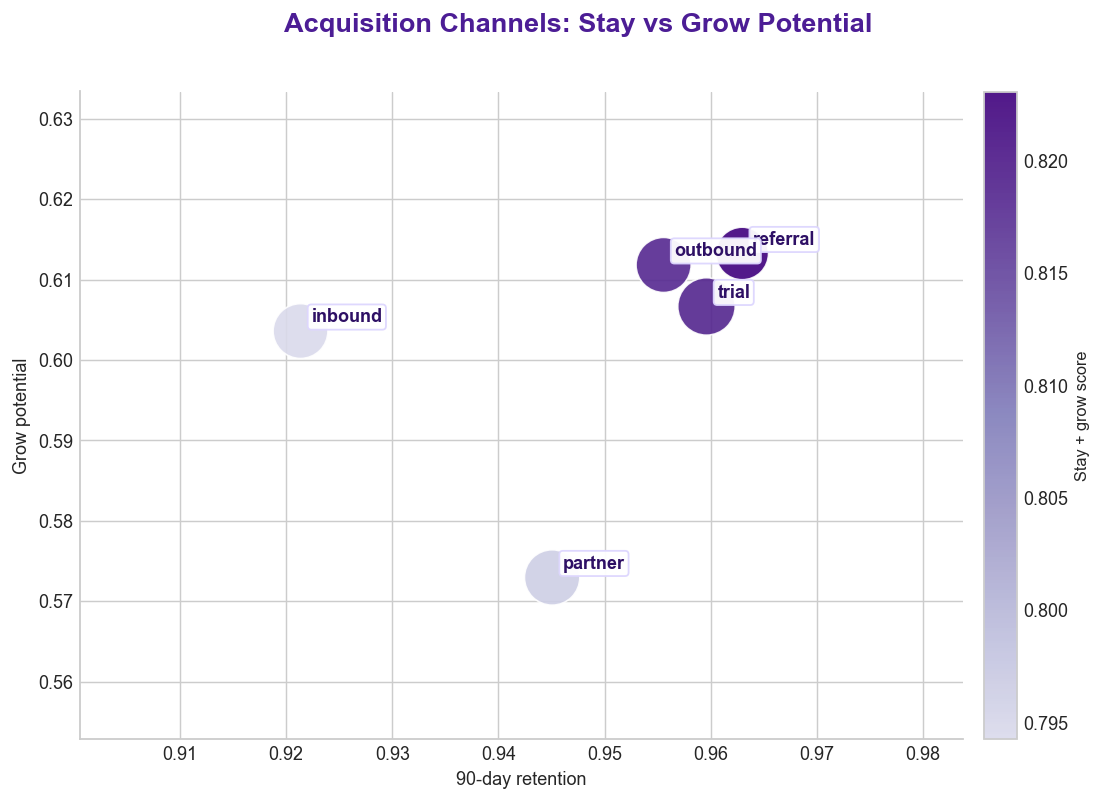

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap

# Defensive check in case this cell is run before analysis cell.
required_frames = ["snapshot_view"]
missing_frames = [name for name in required_frames if name not in globals()]
if missing_frames:
    raise RuntimeError(f"Run the analysis cell first. Missing objects: {missing_frames}")

rank_plot = snapshot_view.sort_values("stay_and_grow_score", ascending=False).copy()

# Use a broadly available style.
for style_name in ["seaborn-whitegrid", "seaborn-v0_8-whitegrid", "ggplot"]:
    if style_name in plt.style.available:
        plt.style.use(style_name)
        break

fig, ax = plt.subplots(figsize=(9, 6), dpi=130)
fig.suptitle("Acquisition Channels: Stay vs Grow Potential", fontsize=15, fontweight="bold", y=1.02, color="#4c1d95")

bubble_sizes = 120 + rank_plot["tenants"].fillna(0) * 9
purple_cmap = LinearSegmentedColormap.from_list("trunc_purples", plt.cm.Purples(np.linspace(0.25, 1.0, 256)))
scatter = ax.scatter(
    rank_plot["retention_90d"],
    rank_plot["grow_potential"],
    s=bubble_sizes,
    c=rank_plot["stay_and_grow_score"],
    cmap=purple_cmap,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.9,
)
for _, row in rank_plot.iterrows():
    ax.annotate(
        row["acquisition_source"],
        (row["retention_90d"], row["grow_potential"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color="#2e1065",
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "#ddd6fe", "alpha": 0.95},
    )

ax.set_xlabel("90-day retention")
ax.set_ylabel("Grow potential")

# Zoom to observed range (with padding) to make between-channel differences clearer.
x_min, x_max = rank_plot["retention_90d"].min(), rank_plot["retention_90d"].max()
y_min, y_max = rank_plot["grow_potential"].min(), rank_plot["grow_potential"].max()
x_pad = max(0.02, (x_max - x_min) * 0.50)
y_pad = max(0.02, (y_max - y_min) * 0.50)
ax.set_xlim(max(0, x_min - x_pad), min(1, x_max + x_pad))
ax.set_ylim(max(0, y_min - y_pad), min(1, y_max + y_pad))

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Stay + grow score", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

out_results = PROJECT_ROOT / "results"
out_results.mkdir(exist_ok=True)
out_png = out_results / "acquisition_channel_stay_grow.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")

plt.show()





